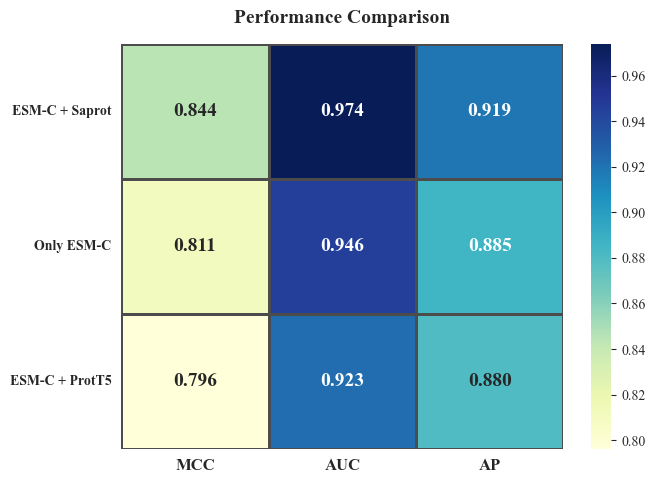

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 设置学术绘图风格 (Publication Quality)
# 设置全局字体为 Times New Roman (常见期刊要求)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 2. 准备数据
# 根据你提供的图片提取的数据 (仅包含 MCC, AUC, AP)
data = {
    'MCC': [0.844, 0.811, 0.796],
    'AUC': [0.974, 0.946, 0.923],
    'AP':  [0.919, 0.885, 0.880]
}

# 对应的模型名称 (行索引)
# 进行了适当的格式化以便阅读
models = [
    'ESM-C + Saprot',
    'Only ESM-C',
    'ESM-C + ProtT5'
]

# 创建 DataFrame
df = pd.DataFrame(data, index=models)

# 3. 绘制热力图
plt.figure(figsize=(7, 5)) # 设置画布大小，符合单栏或半栏插图比例

# 使用 Seaborn 绘制
# cmap='YlGnBu': 黄-绿-蓝渐变，学术界常用，表示数值从低到高
# annot=True: 显示数值
# fmt='.3f': 保留三位小数
# cbar_kws={'label': 'Score'}: 颜色条标签
ax = sns.heatmap(df, 
                 annot=True, 
                 fmt='.3f', 
                 cmap='YlGnBu', 
                 linewidths=1, 
                 linecolor='#4c4c4c', # 单元格分隔线，增加对比度
                 annot_kws={"size": 14, "weight": "bold"}) # 数值字体加粗
                 # cbar_kws={'label': 'Performance Score'})

# 4. 细节调整
# 调整轴标签字体大小和粗细
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=10, rotation=0,weight='bold') # y轴文字水平显示

# 调整颜色条的标签字体
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
# cbar.set_label('Metric Score', size=12, weight='bold')

# 添加标题 (可选，发表时通常写在图注 caption 中，这里为了完整性加上)
plt.title('Performance Comparison', fontsize=14, pad=15, weight='bold')

# 自动调整布局，防止文字被截断
plt.tight_layout()

# 5. 保存图片
# dpi=300: 印刷级分辨率
# bbox_inches='tight': 去除多余白边
plt.savefig('热力图1.png', dpi=300, bbox_inches='tight')
# plt.savefig('model_comparison_heatmap.pdf', dpi=300, bbox_inches='tight') # 同时保存PDF矢量图

# 显示图表
plt.show()

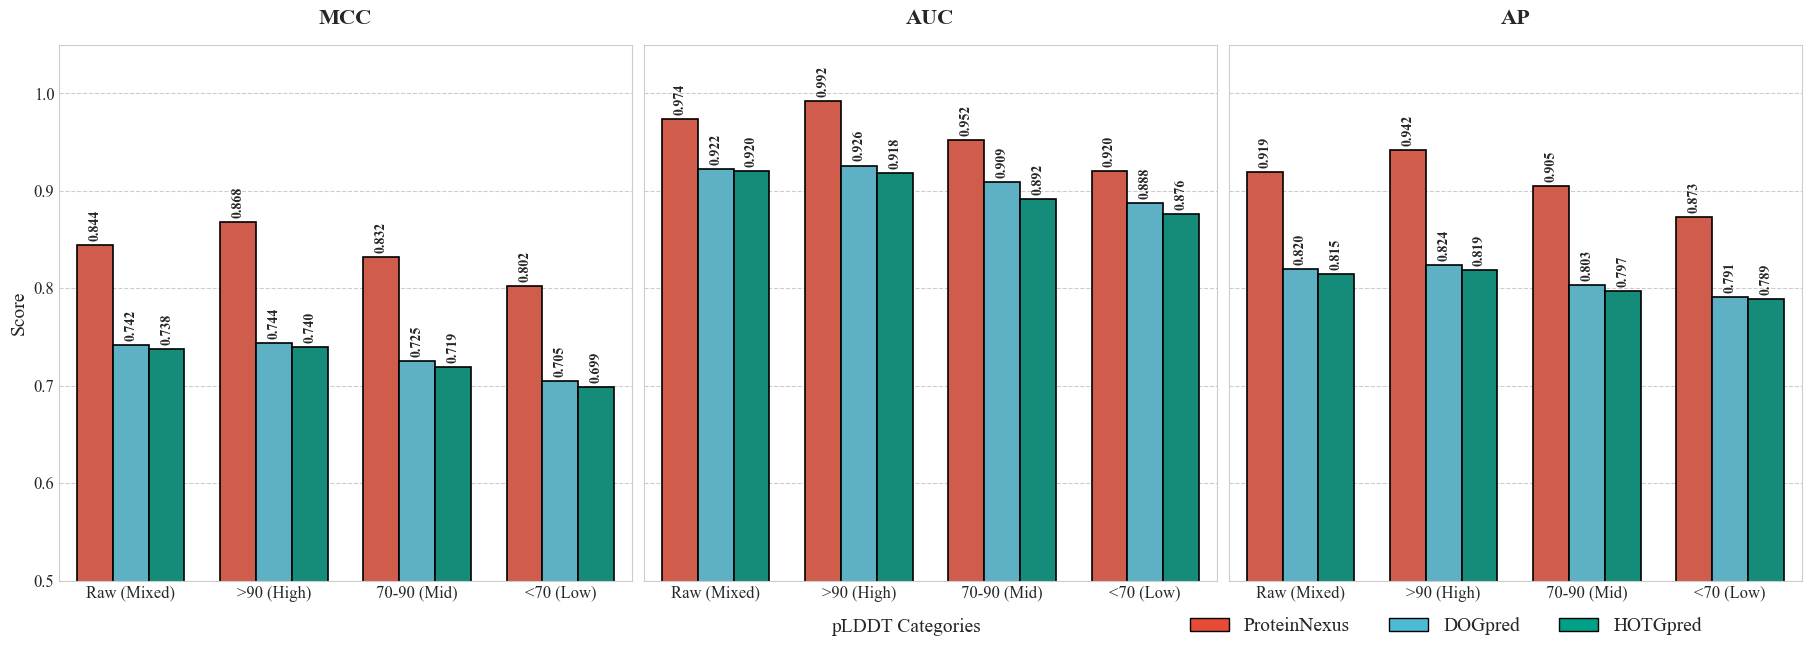

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================
data = {
    'pLDDT Group': [],
    'Model': [],
    'Metric': [],
    'Value': []
}

# 定义组别顺序
groups = ['Raw (Mixed)', '>90 (High)', '70-90 (Mid)', '<70 (Low)']
models = ['ProteinNexus', 'DOGpred', 'HOTGpred']
metrics = ['MCC', 'AUC', 'AP']

# 原始数据
raw_data = {
    'Raw (Mixed)': {
        'ProteinNexus': [0.844, 0.974, 0.919],
        'DOGpred':      [0.742, 0.922, 0.820],
        'HOTGpred':     [0.738, 0.920, 0.815]
    },
    '>90 (High)': {
        'ProteinNexus': [0.868, 0.992, 0.942],
        'DOGpred':      [0.744, 0.926, 0.824],
        'HOTGpred':     [0.740, 0.918, 0.819]
    },
    '70-90 (Mid)': {
        'ProteinNexus': [0.832, 0.952, 0.905],
        'DOGpred':      [0.725, 0.909, 0.803],
        'HOTGpred':     [0.719, 0.892, 0.797]
    },
    '<70 (Low)': {
        'ProteinNexus': [0.802, 0.920, 0.873],
        'DOGpred':      [0.705, 0.888, 0.791],
        'HOTGpred':     [0.699, 0.876, 0.789]
    }
}

# 构建 DataFrame
for group in groups:
    for model in models:
        values = raw_data[group][model]
        # MCC, AUC, AP
        for i, metric in enumerate(metrics):
            data['pLDDT Group'].append(group)
            data['Model'].append(model)
            data['Metric'].append(metric)
            data['Value'].append(values[i])

df = pd.DataFrame(data)

# ==========================================
# 2. 绘图设置 (Paper Quality)
# ==========================================

# 字体设置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False 

# 字号设置
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# 创建画布
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# 颜色与纹理设置
# 使用高对比度学术配色
palette = ["#E64B35", "#4DBBD5", "#00A087"] # 类似 Nature 的配色
hatches = ['', '', ''] # 分别对应三个模型：无纹理、斜线、圆点

# ==========================================
# 3. 循环绘图
# ==========================================

for i, metric in enumerate(metrics):
    ax = axes[i]
    subset = df[df['Metric'] == metric]
    
    # 绘制柱状图
    sns.barplot(
        data=subset,
        x='pLDDT Group',
        y='Value',
        hue='Model',
        ax=ax,
        palette=palette,
        edgecolor='black',
        linewidth=1.2,
        width=0.75
    )
    
    # === 优化点：添加纹理 (Hatching) ===
    # Seaborn barplot 比较难直接加 hatch，需要遍历 patches
    # 计算每个组有几个模型 (这里是3个)
    num_models = len(models)
    bars = ax.patches
    
    # 确保 patches 排序正确后应用纹理
    # Seaborn 的 patches 顺序通常是：所有组的模型1, 所有组的模型2...
    # 但有时顺序会不同，最稳妥的方法是用取余数的方式，或者直接按 hue 分组
    # 这里简单处理：Seaborn 绘制顺序通常是按 hue 顺序绘制整组 bar
    
    # 为每个 bar 分配 hatch
    for j, bar in enumerate(bars):
        # 确定这个 bar 属于哪个模型 (hue)
        # patches 的总数是 len(groups) * len(models)
        # Seaborn barplot 默认是先画所有组的 Model A，再画所有组的 Model B
        hatch_idx = j // len(groups) # 整除组数得到模型索引
        if hatch_idx < len(hatches):
            bar.set_hatch(hatches[hatch_idx])

    # === 优化点：添加数值标签 ===
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, rotation=90,weight='bold')

    # 标题与轴标签
    ax.set_title(metric, fontweight='bold', pad=15)
    ax.set_xlabel('')
    
    # === 优化点：Y轴范围与网格 ===
    # 为了凸显差异，且考虑到最低分也在0.69左右，设置下限为0.5
    ax.set_ylim(0.5, 1.05) # 上限留出空间给数值标签
    
    # 添加水平网格线，置于底层
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
    ax.set_axisbelow(True)

    # Y轴标签只在第一张图显示
    ax.set_ylabel('Score' if i == 0 else '')
    if i > 0:
        ax.set_yticklabels([]) # 隐藏其他图的Y轴刻度值，保持整洁(可选，如果想看刻度可注释掉)
        ax.tick_params(left=False) # 隐藏刻度线

    # 刻度样式
    ax.tick_params(direction='in', length=4, width=1, top=False, right=False)
    
    # 移除子图图例
    if ax.get_legend():
        ax.get_legend().remove()

# ==========================================
# 4. 全局调整
# ==========================================

# 创建自定义图例 (包含颜色和纹理)
import matplotlib.patches as mpatches
legend_patches = []
for m_idx, model in enumerate(models):
    patch = mpatches.Patch(
        facecolor=palette[m_idx], 
        edgecolor='black', 
        hatch=hatches[m_idx], 
        label=model
    )
    legend_patches.append(patch)

fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.8, 0.01), 
           ncol=3, frameon=False, fontsize=MEDIUM_SIZE)

fig.supxlabel('pLDDT Categories', fontsize=MEDIUM_SIZE, y=-0.05)

plt.savefig('plddt_comparison_optimized.png', dpi=500, bbox_inches='tight')
# print("图表已生成：plddt_comparison_optimized.png")
plt.show()

图表已生成：msi_comparison_optimized.png


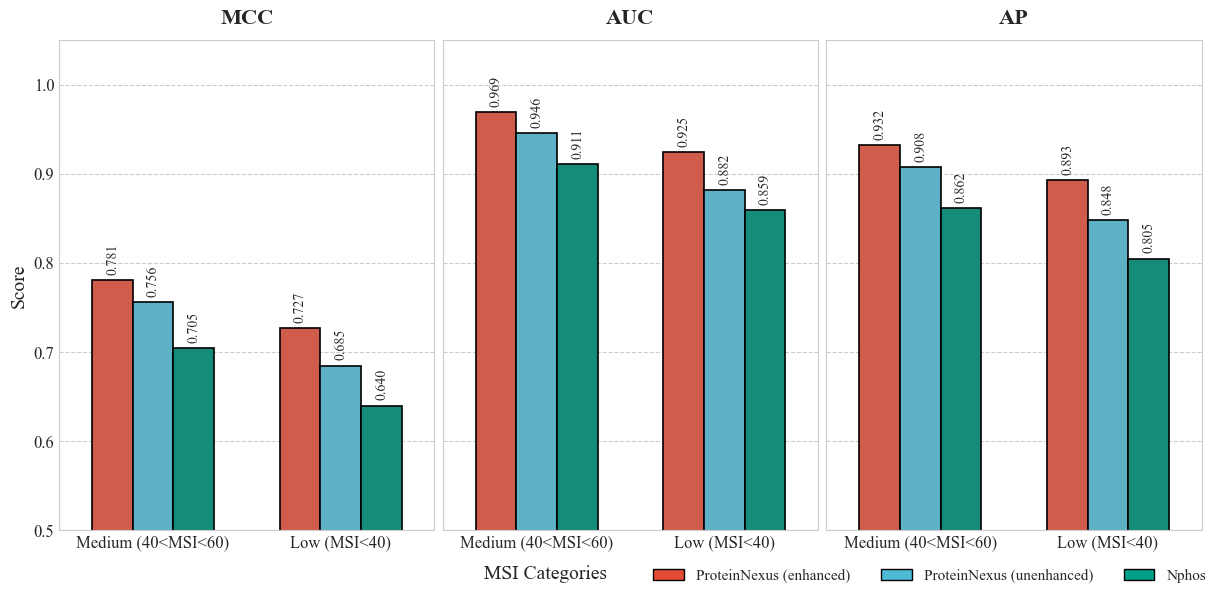

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

# ==========================================
# 1. 数据准备 (针对 MSI 实验组)
# ==========================================
data = {
    'Group': [],
    'Model': [],
    'Metric': [],
    'Value': []
}

# 定义组别顺序
groups = ['Medium (40<MSI<60)', 'Low (MSI<40)']

# 模型定义
models = ['ProteinNexus (enhanced)', 'ProteinNexus (unenhanced)', 'Nphos']
metrics = ['MCC', 'AUC', 'AP']

# 原始数据
raw_data = {
    'Medium (40<MSI<60)': {
        'ProteinNexus (enhanced)':   [0.781, 0.969, 0.932],
        'ProteinNexus (unenhanced)': [0.756, 0.946, 0.908],
        'Nphos':                     [0.705, 0.911, 0.862]
    },
    'Low (MSI<40)': {
        'ProteinNexus (enhanced)':   [0.727, 0.925, 0.893],
        'ProteinNexus (unenhanced)': [0.685, 0.882, 0.848],
        'Nphos':                     [0.640, 0.859, 0.805]
    }
}

# 构建 DataFrame
for group in groups:
    for model in models:
        values = raw_data[group][model]
        for i, metric in enumerate(metrics):
            data['Group'].append(group)
            data['Model'].append(model)
            data['Metric'].append(metric)
            data['Value'].append(values[i])

df = pd.DataFrame(data)

# ==========================================
# 2. 绘图设置 (论文级排版优化)
# ==========================================

# 字体设置 - 确保与论文正文一致 (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False 

# 字号系统 - 统一管理
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# 创建画布
# 优化点：缩小宽度 (从16改为12)，因为只有2个组，太宽会显得空旷
fig, axes = plt.subplots(1, 3, figsize=(12, 5.5), constrained_layout=True)

# 配色方案 (Nature/Science 风格)
palette = ["#E64B35", "#4DBBD5", "#00A087"] 
hatches = ['', '', ''] 

# ==========================================
# 3. 循环绘图
# ==========================================

for i, metric in enumerate(metrics):
    ax = axes[i]
    subset = df[df['Metric'] == metric]
    
    # 绘制柱状图
    sns.barplot(
        data=subset,
        x='Group',
        y='Value',
        hue='Model',
        ax=ax,
        palette=palette,
        edgecolor='black',
        linewidth=1.2,
        width=0.65  # 优化点：微调柱宽
    )
    
    # === 纹理处理 (Hatching) ===
    # Seaborn 按照 hue 分组绘制 (先画所有组的模型A，再画模型B...)
    bars = ax.patches
    bars_per_model = len(groups) # 每个模型有2个柱子(对应2个组)
    
    for j, bar in enumerate(bars):
        hatch_idx = j // bars_per_model
        if hatch_idx < len(hatches):
            bar.set_hatch(hatches[hatch_idx])

    # === 数值标签优化 ===
    # 优化点：旋转90度，放置在柱子内部或顶部，避免拥挤
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=4, fontsize=10, rotation=90)

    # 标题与轴标签
    ax.set_title(metric, fontweight='bold', pad=12)
    ax.set_xlabel('')
    
    # === Y轴范围与网格 ===
    # 优化点：设置上限为1.15，为旋转的标签留出足够空间
    ax.set_ylim(0.5, 1.05) 
    
    # 网格线置于底层
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
    ax.set_axisbelow(True)

    # Y轴标签只在第一张图显示
    ax.set_ylabel('Score' if i == 0 else '')
    if i > 0:
        ax.set_yticklabels([]) 
        ax.tick_params(left=False) 

    # 刻度样式 (朝内)
    ax.tick_params(direction='in', length=4, width=1, top=False, right=False)
    
    # 移除子图图例
    if ax.get_legend():
        ax.get_legend().remove()

# ==========================================
# 4. 全局图例与保存
# ==========================================

# 创建自定义图例
legend_patches = []
for m_idx, model in enumerate(models):
    patch = mpatches.Patch(
        facecolor=palette[m_idx], 
        edgecolor='black', 
        hatch=hatches[m_idx], 
        label=model
    )
    legend_patches.append(patch)

# 图例位置优化：适应变窄的画布
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.77, 0.001), 
           ncol=3, frameon=False, fontsize=11)

# 公共 X 轴标签
fig.supxlabel('MSI Categories', fontsize=MEDIUM_SIZE, y=-0.05,x=0.45)

# 保存高分辨率图片
plt.savefig('msi_comparison_optimized.png', dpi=500, bbox_inches='tight')
print("图表已生成：msi_comparison_optimized.png")

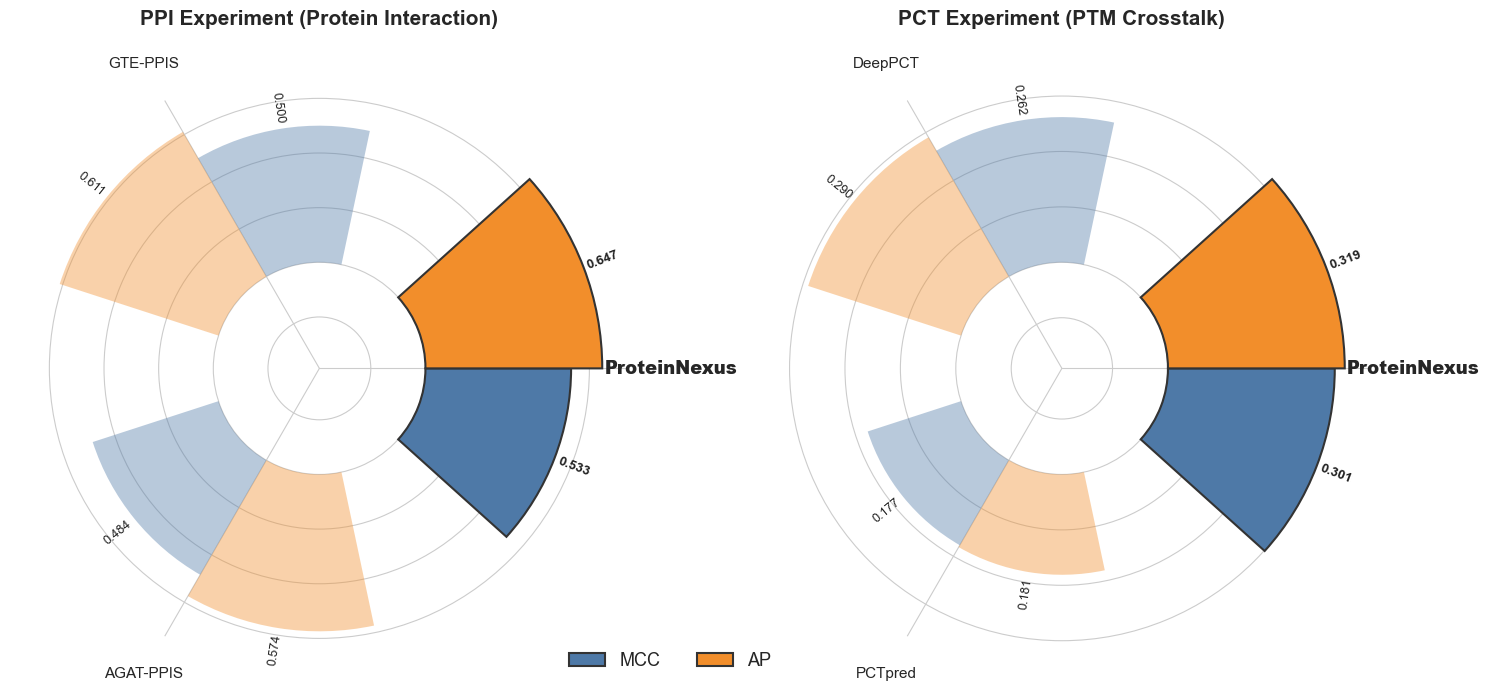

In [131]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================

# PPI 实验数据
ppi_labels = ['ProteinNexus', 'GTE-PPIS', 'AGAT-PPIS']
ppi_mcc = [0.533, 0.500, 0.484]
ppi_ap  = [0.647, 0.611, 0.574]

# PCT 实验数据
pct_labels = ['ProteinNexus', 'DeepPCT', 'PCTpred']
pct_mcc = [0.301, 0.262, 0.177]
pct_ap  = [0.319, 0.290, 0.181]

# 指标名称与颜色配置
metrics = ['MCC', 'AP']
# 使用稍微深一点的颜色，以便在降低透明度时仍然清晰
colors = ['#4E79A7', '#F28E2B']  # Tableau 风格: 深蓝 (MCC), 橙色 (AP)

# ==========================================
# 2. 绘图函数定义
# ==========================================

def draw_circular_barplot(ax, labels, data_mcc, data_ap, title):
    """
    在指定的极坐标轴 ax 上绘制环形分组柱状图，并高亮 ProteinNexus
    """
    N = len(labels)
    
    # 计算角度
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    # 增加一点宽度，让柱子更饱满
    width = (2 * np.pi / N) * 0.35
    
    # 调整柱子的起始角度
    theta_mcc = angles - width/2
    theta_ap  = angles + width/2
    
    # 绘制基础柱状图 (先不设置统一alpha，后面循环单独设置)
    bars_mcc = ax.bar(theta_mcc, data_mcc, width=width, color=colors[0], label='MCC', zorder=3)
    bars_ap  = ax.bar(theta_ap,  data_ap,  width=width, color=colors[1], label='AP', zorder=3)
    
    # ==========================================
    # 3. 视觉高亮逻辑 (Highlighting)
    # ==========================================
    for i, label in enumerate(labels):
        # 判断是否为最优模型
        is_best = (label == 'ProteinNexus')
        
        # 样式配置
        # 最优模型：不透明(1.0)，有边框
        # 其他模型：半透明(0.4)，无边框，颜色变淡以衬托最优模型
        alpha_val = 1.0 if is_best else 0.4 
        edge_color = '#333333' if is_best else 'none'
        line_width = 1.5 if is_best else 0
        
        # 应用样式到 MCC 柱子
        bars_mcc[i].set_alpha(alpha_val)
        bars_mcc[i].set_edgecolor(edge_color)
        bars_mcc[i].set_linewidth(line_width)
        
        # 应用样式到 AP 柱子
        bars_ap[i].set_alpha(alpha_val)
        bars_ap[i].set_edgecolor(edge_color)
        bars_ap[i].set_linewidth(line_width)

    # ==========================================
    # 4. 动态刻度与美化
    # ==========================================
    
    # 动态计算该组数据的最大值，实现独立刻度
    # 这样 PPI 和 PCT 无论数值大小如何，都会画出饱满的圆环
    max_val = max(max(data_mcc), max(data_ap))
    
    # 设置中心镂空大小 (负值越小，空心越大)
    # 使用 max_val 比例来设置，保证空心比例一致
    ax.set_ylim(-max_val * 0.6, max_val * 1.15) 
    
    # 隐藏 y 轴刻度数字
    ax.set_yticklabels([])
    
    # 设置 x 轴标签 (模型名称)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=11)
    
    # 高亮 "ProteinNexus" 的文字标签
    for label_obj in ax.get_xticklabels():
        if label_obj.get_text() == 'ProteinNexus':
            label_obj.set_fontweight('heavy') # 极粗
            label_obj.set_fontsize(13)        # 加大字号
            # label_obj.set_color('#B22222')  # 可选：变成深红色
    
    # 调整标签距离
    ax.tick_params(axis='x', pad=20)
    
    # # 网格线
    # ax.grid(True, linestyle='--', alpha=0.4, color='gray', zorder=0)
    ax.spines['polar'].set_visible(False)
    
    # 标题
    ax.set_title(title, pad=25, fontsize=15, fontweight='bold')
    
    # 添加数值标签
    def add_labels(bars, data):
        for i, (bar, val) in enumerate(zip(bars, data)):
            is_best = (labels[i] == 'ProteinNexus')
            
            height = bar.get_height()
            angle = bar.get_x() + bar.get_width() / 2
            rotation = np.degrees(angle)
            if 90 < rotation < 270:
                rotation += 180
            
            # 最优模型的数值也加粗
            fw = 'bold' if is_best else 'normal'
            fs = 9.5 if is_best else 9
            
            ax.text(angle, height + max_val*0.12, f'{val:.3f}', 
                    ha='center', va='center', rotation=rotation, 
                    fontsize=fs, fontweight=fw, color='#222222')

    add_labels(bars_mcc, data_mcc)
    add_labels(bars_ap, data_ap)

    return bars_mcc, bars_ap

# ==========================================
# 5. 主程序
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(15, 8))

# 绘制 PPI
bars_mcc_ppi, bars_ap_ppi = draw_circular_barplot(ax1, ppi_labels, ppi_mcc, ppi_ap, "PPI Experiment (Protein Interaction)")

# 绘制 PCT
bars_mcc_pct, bars_ap_pct = draw_circular_barplot(ax2, pct_labels, pct_mcc, pct_ap, "PCT Experiment (PTM Crosstalk)")

# 添加图例 (只取一组句柄即可，颜色是一样的)
legend = fig.legend([bars_mcc_ppi[0], bars_ap_ppi[0]], metrics, 
                    loc='lower center', ncol=2, 
                    frameon=False, fontsize=13, bbox_to_anchor=(0.45, 0.15))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12) # 留出底部空间给图例

plt.savefig('PPI,PCT.png', dpi=500, bbox_inches='tight')
plt.show()

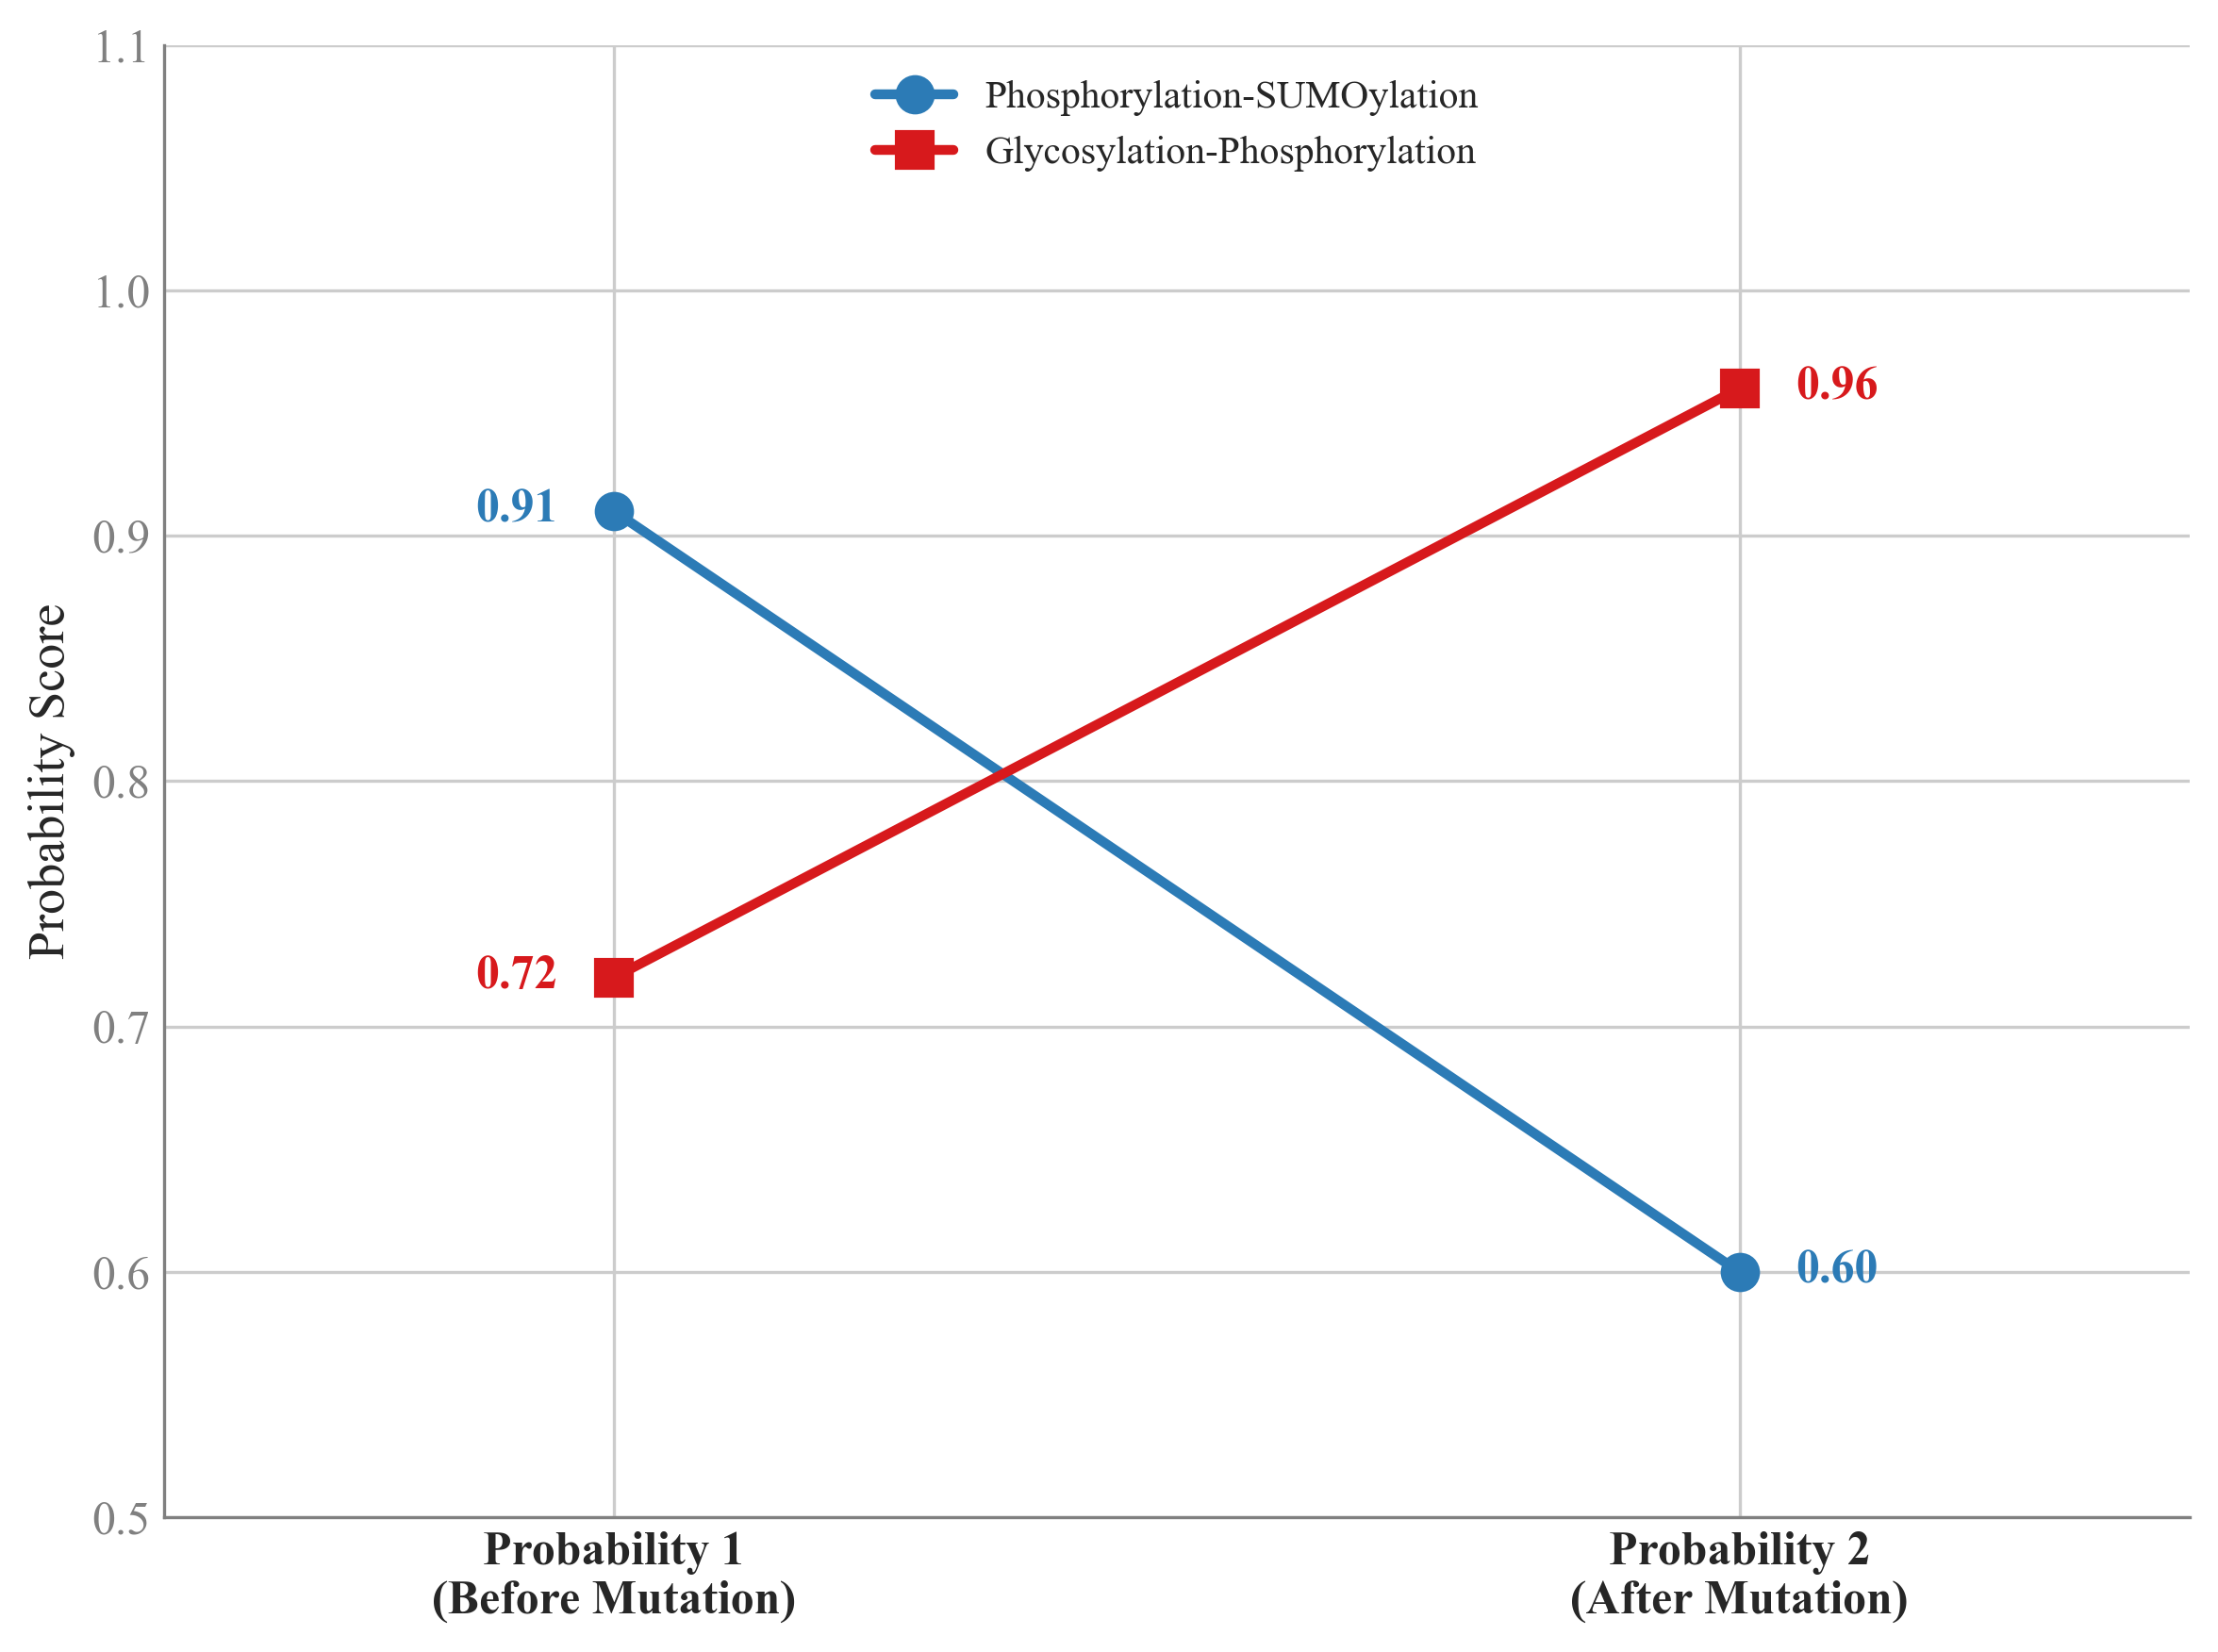

In [138]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# -----------------------
# 数据准备
# -----------------------
# 类别标签
x_labels = ['Probability 1\n(Before Mutation)', 'Probability 2\n(After Mutation)']
# 数据点
y_data = {
    'Phosphorylation-SUMOylation': {'values': [0.91, 0.60], 'color': '#2C7BB6', 'marker': 'o'},  # 蓝色，下降
    'Glycosylation-Phosphorylation': {'values': [0.72, 0.96], 'color': '#D7191C', 'marker': 's'}   # 红色，上升
}

# -----------------------
# 绘图设置
# -----------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# 设置字体 (尝试使用衬线体，如果没有则回退到默认)
plt.rcParams['font.family'] = 'serif' 

# 绘制线条和点
for label, data in y_data.items():
    y = data['values']
    color = data['color']
    marker = data['marker']
    
    # 画线
    ax.plot([0, 1], y, color=color, linewidth=2.5, marker=marker, markersize=9, label=label)
    
    # -----------------------
    # 核心优化：数值直接标注
    # -----------------------
    # 左侧数值 (Probability 1)
    ax.text(-0.05, y[0], f'{y[0]:.2f}', color=color, fontsize=12, fontweight='bold', 
            ha='right', va='center')
    
    # 右侧数值 (Probability 2)
    ax.text(1.05, y[1], f'{y[1]:.2f}', color=color, fontsize=12, fontweight='bold', 
            ha='left', va='center')

# -----------------------
# 美化布局
# -----------------------
# X轴设置
ax.set_xticks([0, 1])
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_xlim(-0.4, 1.4) # 留出更多边距给文字

# Y轴设置
ax.set_ylim(0.5, 1.1)
ax.set_ylabel('Probability Score', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')
ax.tick_params(axis='y', colors='gray') # Y轴刻度颜色变淡，不抢眼

# 添加淡网格
# ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')

# -----------------------
# 图例优化
# -----------------------
# 将图例放在顶部，横向排列，更加整洁
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=1, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('关联.png', dpi=300, bbox_inches='tight')
plt.show()

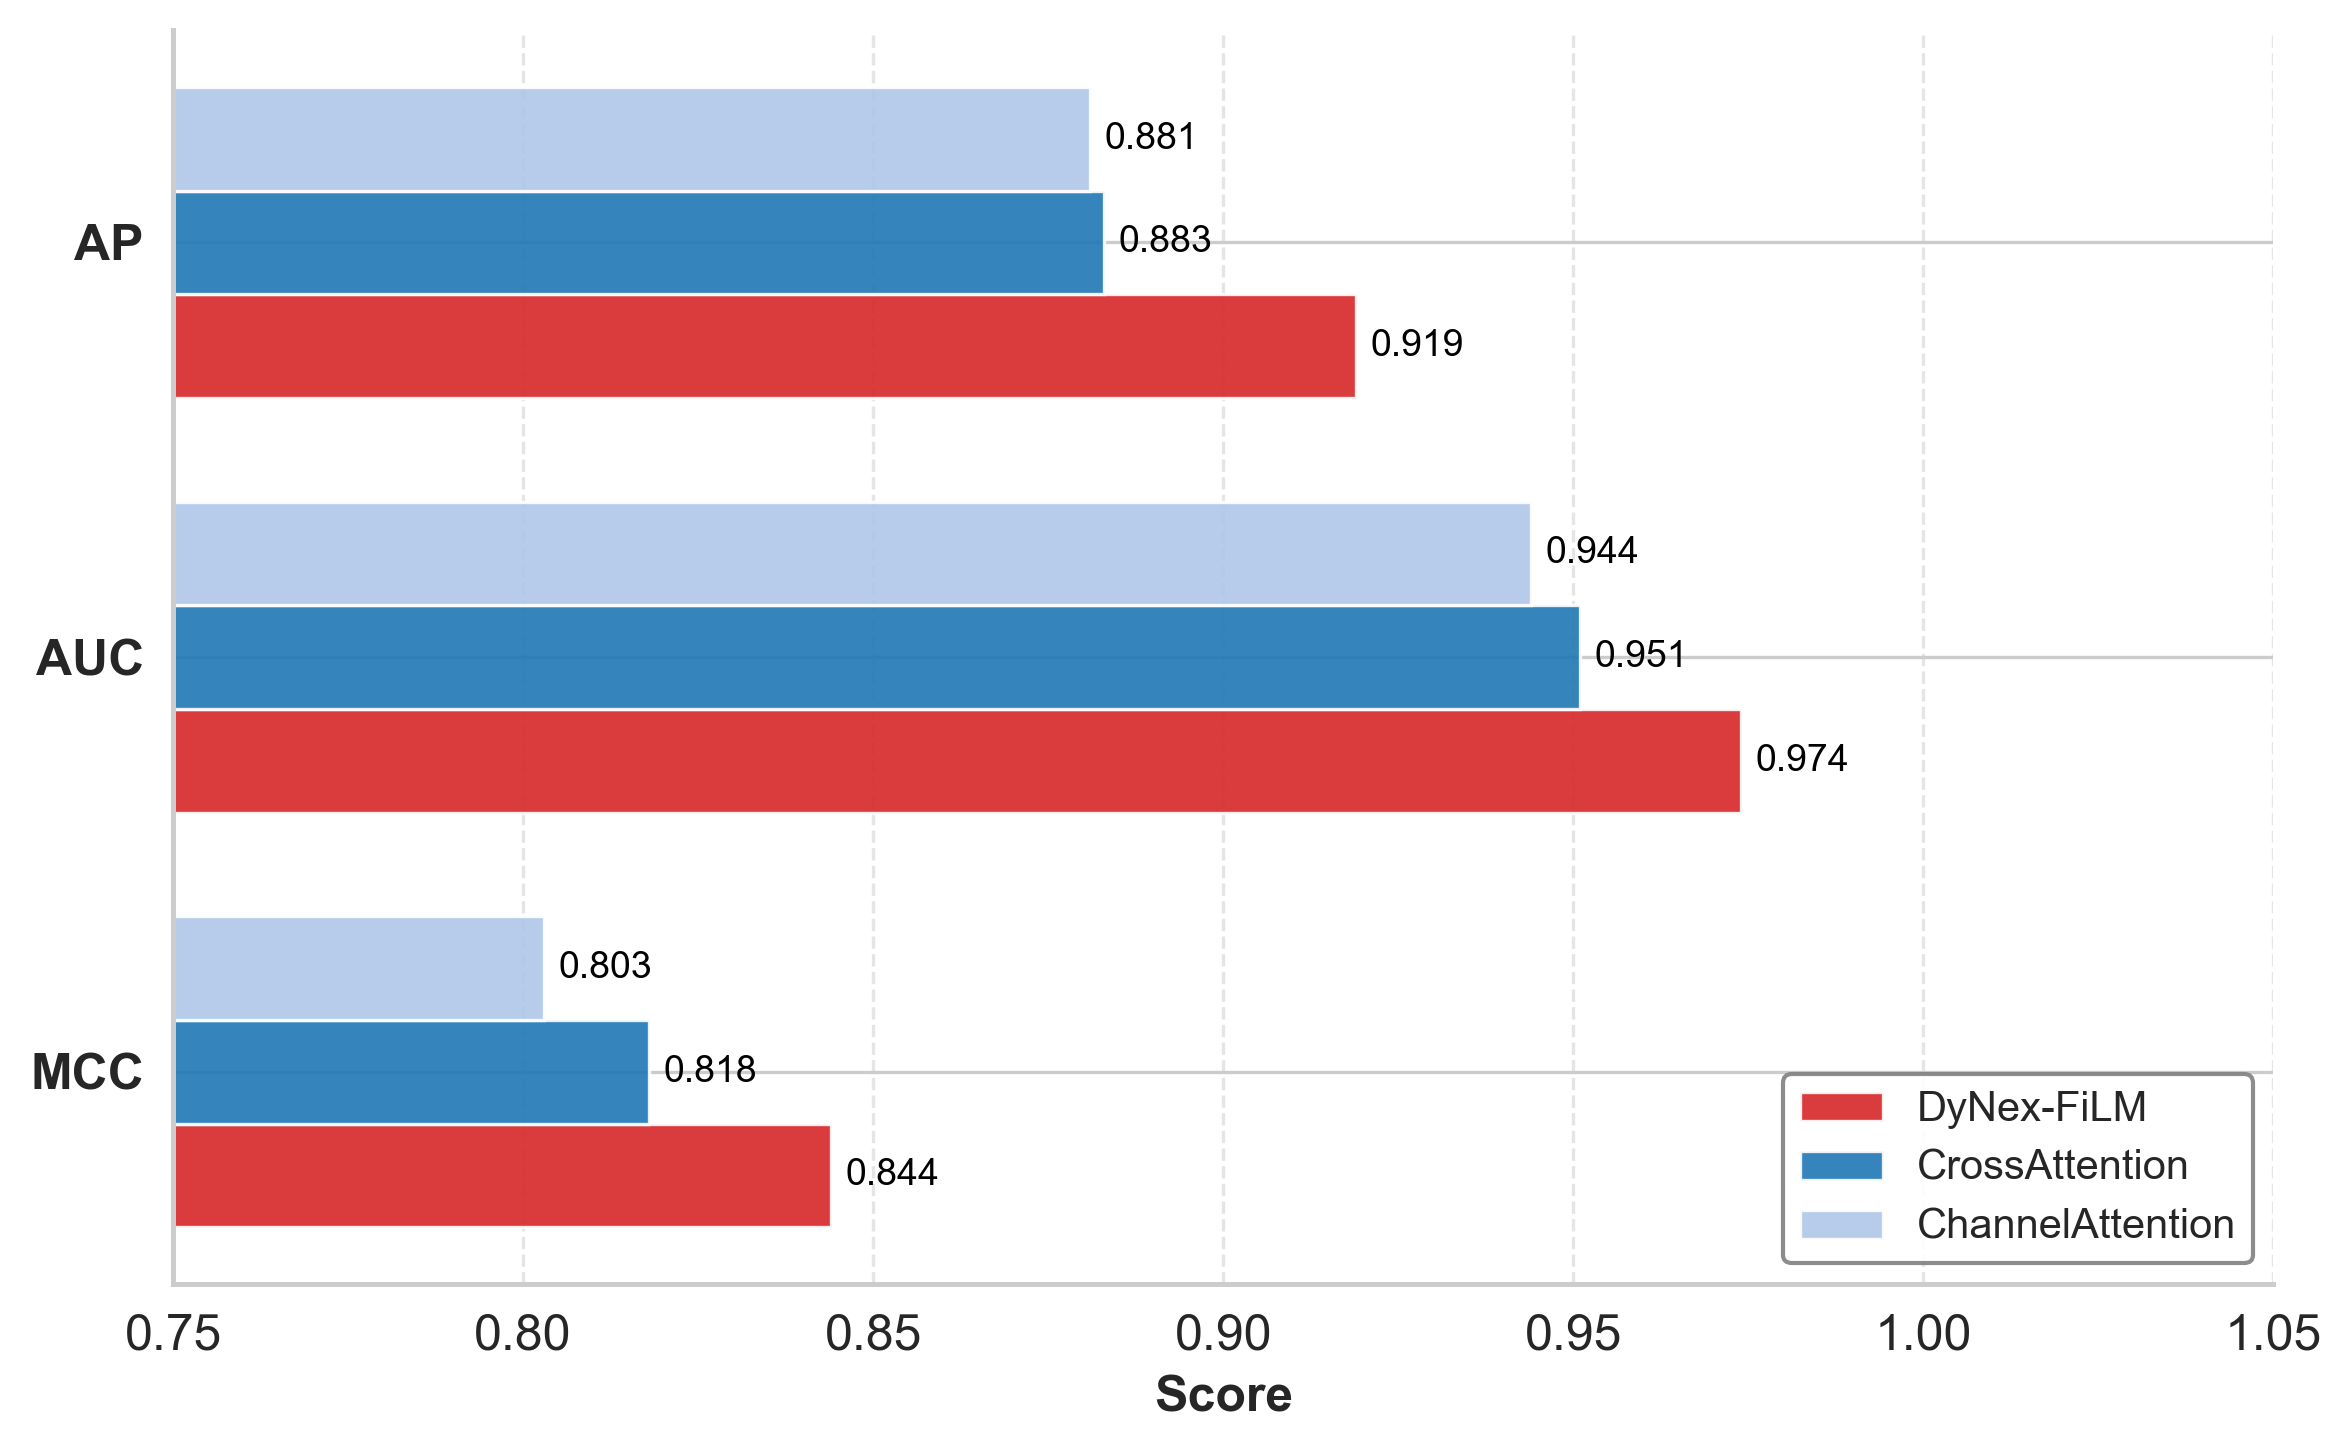

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================
models = ['DyNex-FiLM', 'CrossAttention', 'ChannelAttention']
metrics = ['MCC', 'AUC', 'AP']

# 数据对应关系:
# DyNex-FiLM:      MCC=0.844, AUC=0.974, AP=0.919
# CrossAttention:  MCC=0.818, AUC=0.951, AP=0.883
# ChannelAttention: MCC=0.803, AUC=0.944, AP=0.881

data = {
    'DyNex-FiLM':      [0.844, 0.974, 0.919],
    'CrossAttention':  [0.818, 0.951, 0.883],
    'ChannelAttention': [0.803, 0.944, 0.881]
}

# ==========================================
# 2. 绘图设置 (符合论文规范)
# ==========================================
# 设置字体，优先使用 Arial 或 Times New Roman
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans'] 
plt.rcParams['font.size'] = 12

# 定义颜色方案
# DyNex-FiLM 使用醒目的颜色 (例如: 砖红色/深橙色)
# 其他对比模型使用冷色调/灰色调 (例如: 深蓝, 浅蓝)
colors = ['#D62728', '#1F77B4', '#AEC7E8'] # Matplotlib tab10 风格: 红, 蓝, 浅蓝
# 或者更素雅的学术灰度风格：
# colors = ['#333333', '#777777', '#BBBBBB'] 

# 柱状图参数
bar_height = 0.25  # 每个柱子的高度
index = np.arange(len(metrics))  # 指标的位置索引 [0, 1, 2]

# 创建画布
fig, ax = plt.subplots(figsize=(8, 5), dpi=300) # 宽8英寸，高5英寸，300 DPI

# ==========================================
# 3. 绘制横向柱状图
# ==========================================
# 绘制每一组柱子
# 注意：y轴坐标需要根据柱子高度进行偏移，使它们聚在一起
for i, model in enumerate(models):
    # 计算每个柱子的y轴位置
    # index 是中心位置
    # len(models)/2 * bar_height 是偏移量的一半
    y_pos = index + (i - len(models)/2 + 0.5) * bar_height
    
    rects = ax.barh(y_pos, data[model], height=bar_height, label=model, 
                    color=colors[i], edgecolor='white', linewidth=0.8, alpha=0.9)
    
    # 在柱子旁边添加数值标签
    for rect in rects:
        width = rect.get_width()
        # x位置偏移量设为0.002，防止标签紧贴柱子
        ax.text(width + 0.002, rect.get_y() + rect.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9, color='black')

# ==========================================
# 4. 美化与细节调整
# ==========================================

# 设置Y轴刻度标签 (指标名称)
ax.set_yticks(index)
ax.set_yticklabels(metrics, fontsize=12, fontweight='bold')

# 设置X轴范围
# 稍微增加上限到1.05，给数值标签留出空间
ax.set_xlim(0.75, 1.05) 
ax.set_xlabel('Score', fontsize=12, fontweight='bold')

# 添加图例 (位置设为最佳，去除边框以保持整洁)
ax.legend(loc='lower right', frameon=True, framealpha=0.9, edgecolor='gray', fontsize=10)

# 移除顶部和右侧的边框 (Spines) - 这是论文图表的常见规范
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 加粗左侧和底部边框
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 添加垂直网格线 (帮助读取数值)，置于图层底部
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 调整布局防止标签被截断
plt.tight_layout()

# 保存图片 (PDF格式适合投稿，PNG适合预览)
plt.savefig('dyNex.png', format='png', bbox_inches='tight', dpi=400)
# plt.savefig('model_comparison_chart.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.show()

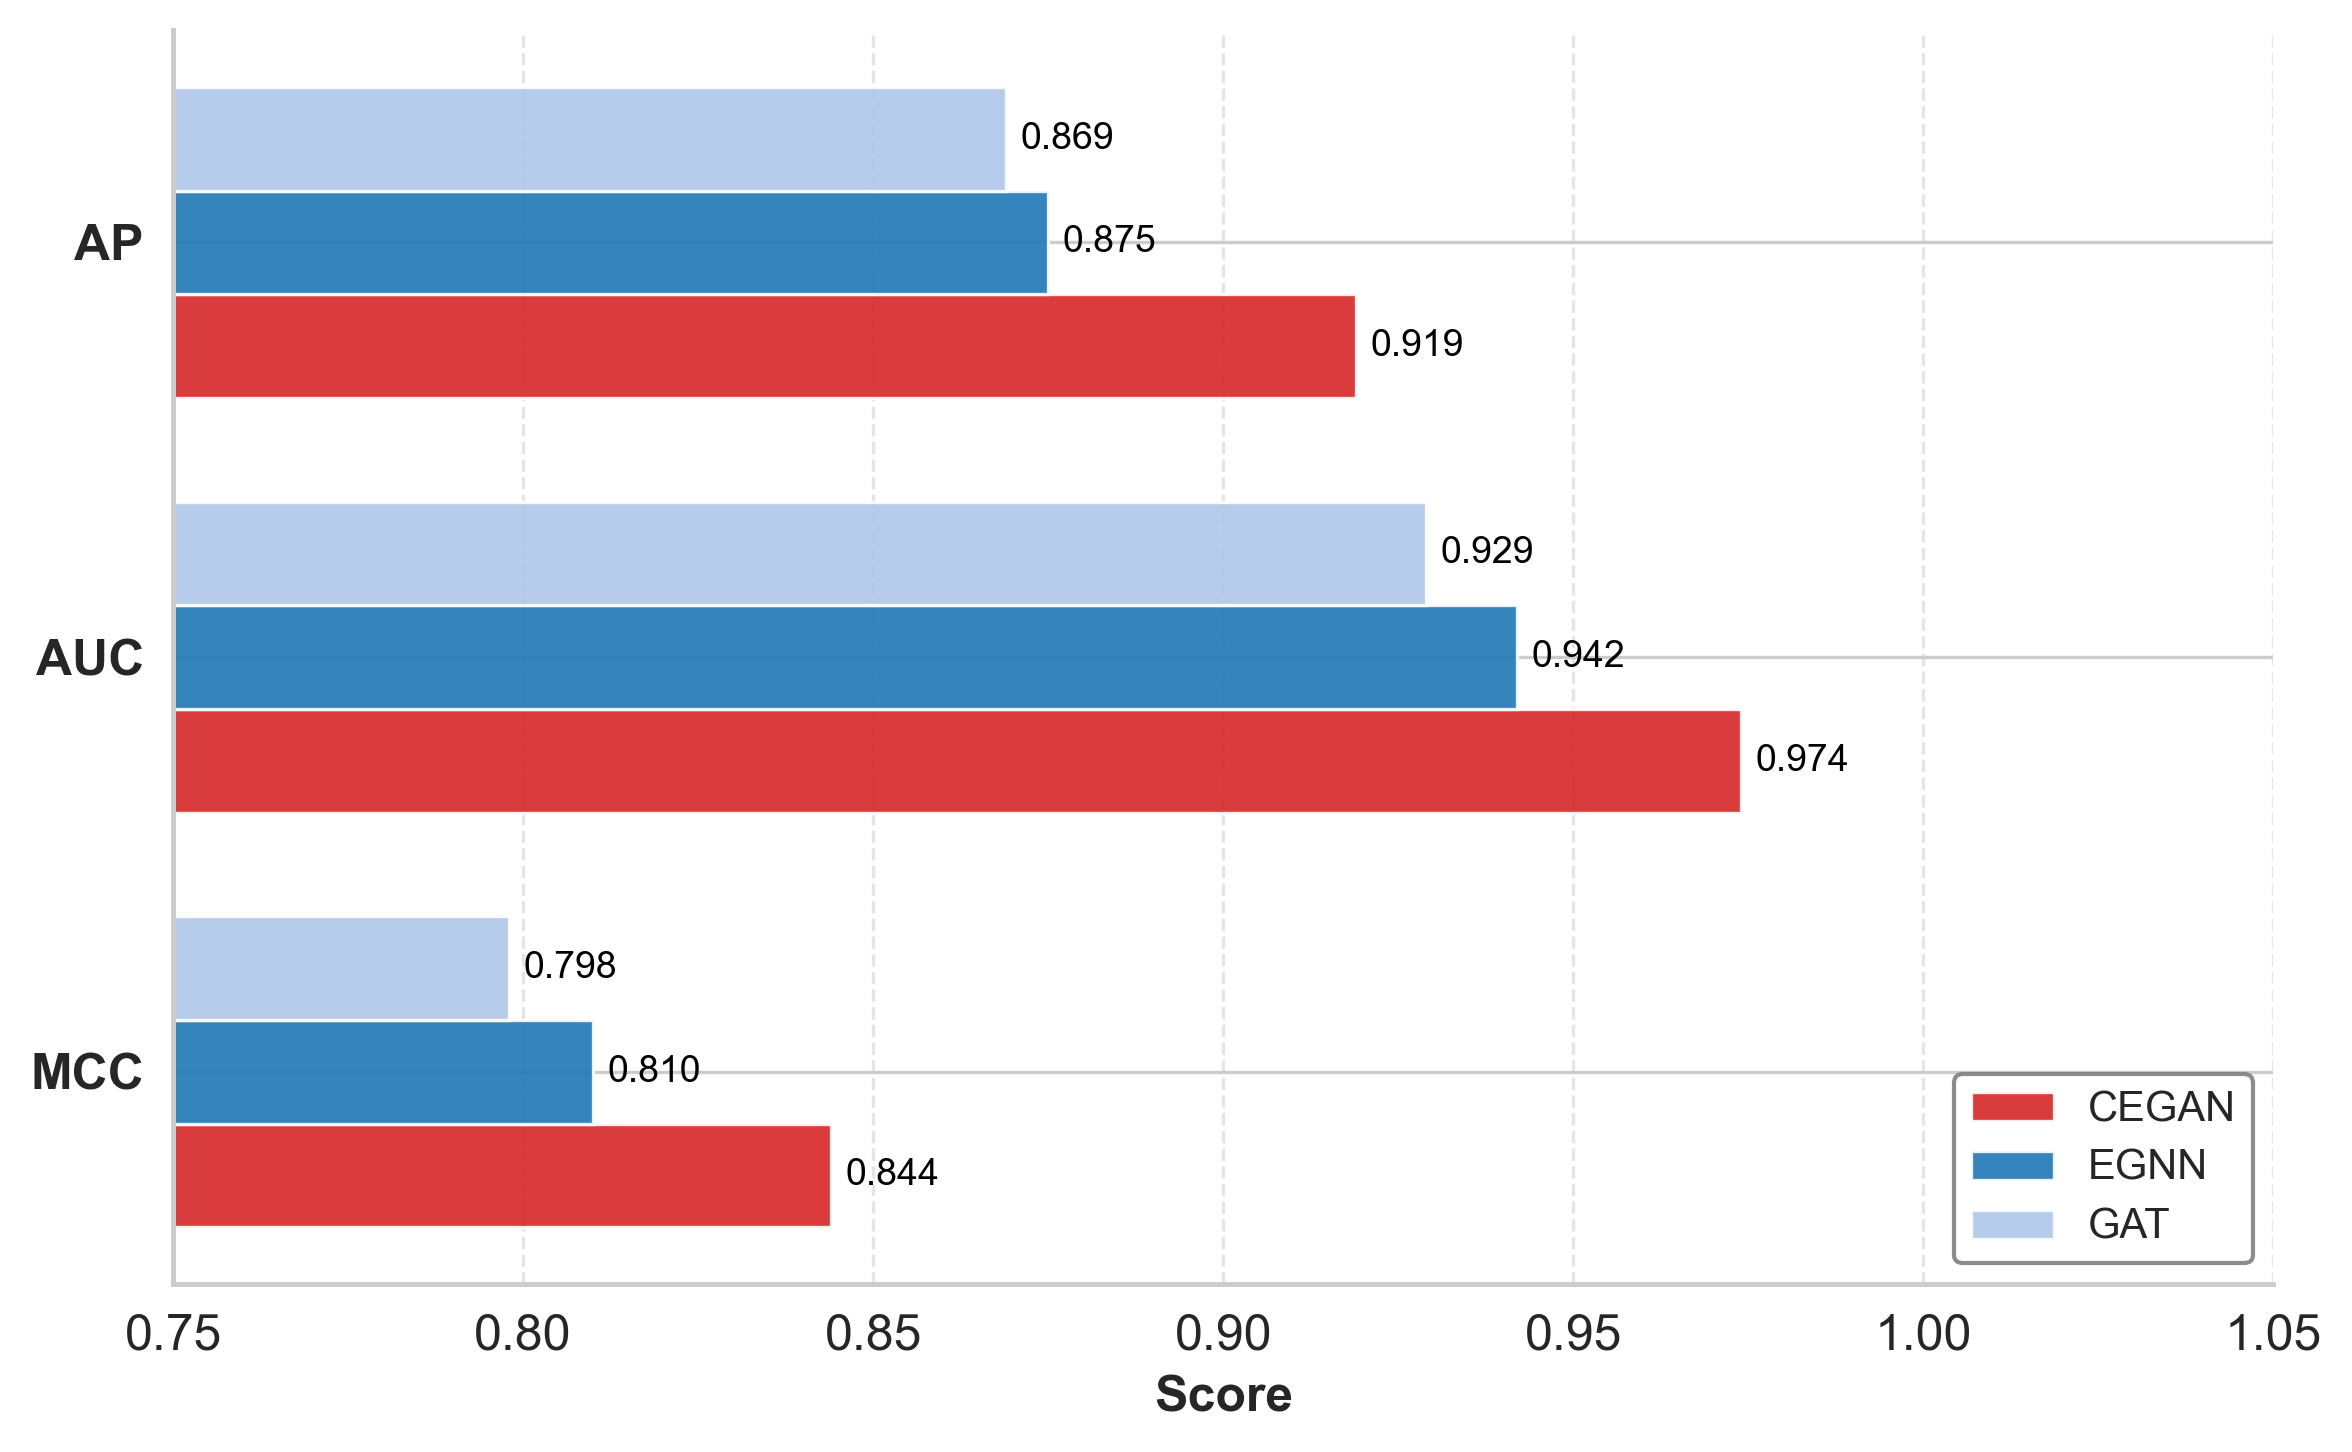

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================
models = ['CEGAN', 'EGNN', 'GAT']
metrics = ['MCC', 'AUC', 'AP']

# 数据对应关系:
# DyNex-FiLM:      MCC=0.844, AUC=0.974, AP=0.919
# CrossAttention:  MCC=0.818, AUC=0.951, AP=0.883
# ChannelAttention: MCC=0.803, AUC=0.944, AP=0.881

data = {
    'CEGAN':      [0.844, 0.974, 0.919],
    'EGNN':  [0.810, 0.942, 0.875],
    'GAT': [0.798, 0.929, 0.869]
}

# ==========================================
# 2. 绘图设置 (符合论文规范)
# ==========================================
# 设置字体，优先使用 Arial 或 Times New Roman
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans'] 
plt.rcParams['font.size'] = 12

# 定义颜色方案
# DyNex-FiLM 使用醒目的颜色 (例如: 砖红色/深橙色)
# 其他对比模型使用冷色调/灰色调 (例如: 深蓝, 浅蓝)
colors = ['#D62728', '#1F77B4', '#AEC7E8'] # Matplotlib tab10 风格: 红, 蓝, 浅蓝
# 或者更素雅的学术灰度风格：
# colors = ['#333333', '#777777', '#BBBBBB'] 

# 柱状图参数
bar_height = 0.25  # 每个柱子的高度
index = np.arange(len(metrics))  # 指标的位置索引 [0, 1, 2]

# 创建画布
fig, ax = plt.subplots(figsize=(8, 5), dpi=300) # 宽8英寸，高5英寸，300 DPI

# ==========================================
# 3. 绘制横向柱状图
# ==========================================
# 绘制每一组柱子
# 注意：y轴坐标需要根据柱子高度进行偏移，使它们聚在一起
for i, model in enumerate(models):
    # 计算每个柱子的y轴位置
    # index 是中心位置
    # len(models)/2 * bar_height 是偏移量的一半
    y_pos = index + (i - len(models)/2 + 0.5) * bar_height
    
    rects = ax.barh(y_pos, data[model], height=bar_height, label=model, 
                    color=colors[i], edgecolor='white', linewidth=0.8, alpha=0.9)
    
    # 在柱子旁边添加数值标签
    for rect in rects:
        width = rect.get_width()
        # x位置偏移量设为0.002，防止标签紧贴柱子
        ax.text(width + 0.002, rect.get_y() + rect.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9, color='black')

# ==========================================
# 4. 美化与细节调整
# ==========================================

# 设置Y轴刻度标签 (指标名称)
ax.set_yticks(index)
ax.set_yticklabels(metrics, fontsize=12, fontweight='bold')

# 设置X轴范围
# 稍微增加上限到1.05，给数值标签留出空间
ax.set_xlim(0.75, 1.05) 
ax.set_xlabel('Score', fontsize=12, fontweight='bold')

# 添加图例 (位置设为最佳，去除边框以保持整洁)
ax.legend(loc='lower right', frameon=True, framealpha=0.9, edgecolor='gray', fontsize=10)

# 移除顶部和右侧的边框 (Spines) - 这是论文图表的常见规范
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 加粗左侧和底部边框
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 添加垂直网格线 (帮助读取数值)，置于图层底部
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 调整布局防止标签被截断
plt.tight_layout()

# 保存图片 (PDF格式适合投稿，PNG适合预览)
plt.savefig('CEGAN.png', format='png', bbox_inches='tight', dpi=400)
# plt.savefig('model_comparison_chart.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.show()